# AI-Based Voltage Estimation Tutorial | <font color=red>Part 1</font>: Keras-Based LV Voltage Estimation

## 1. Introduction

### Objectives

The objectives of this tutorial are:

1. To familiarise yourself with how power engineers can estimate **customer voltage magnitudes (V) from active power (P) and reactive power (Q)** in a low-voltage (LV) distribution network. You will use a **neural network**, a model that learns this relationship from examples. All power and voltage data are **simulated**, not measurements from real customers.

2. To become familiar with **Keras**, a Python tool for building and training neural networks. You will prepare the data, train a model and check its voltage estimates in a Jupyter notebook. Training means adjusting the model using examples. This tutorial is intended for **electrical engineering students in the Power specialization**; **no previous knowledge of neural networks is required**. New concepts are explained when they are needed.

3. To understand why a neural network can be useful for voltage estimation when a detailed LV network model is unavailable or difficult to maintain. You will compare this data-driven approach with a traditional power-flow calculation, which requires network topology, phase connections, impedances and an upstream voltage. A neural network can provide fast estimates after training, but it depends on representative data.


### Structure of this Notebook

The rest of this notebook is divided into three parts:

- **2. Tutorial.**
    - You will learn, step by step, how to prepare simulated data and train a Keras model to estimate customer voltages.
    - You will learn how to compare model settings and check voltage estimates and errors on separate test data.
- **3. Exercises.** You will first modify a neural network and compare its validation errors, then train and test your selected voltage estimator.
- **4. Exercise Workspace.** Use the relevant tutorial code to complete each numbered task and display its results.

<font color='red'>**<u>Note</u>:**</font> Work through **2. Tutorial** before attempting the exercises. Make sure you understand which data are used to train the model, which are used to choose its settings, and which are reserved for the final check.


## 2. Tutorial

Follow the sections in order. Each step introduces the relevant code, the settings you can change and the output to inspect. Start with the **quick** training mode in Section 2.5.1.


### 2.1 Test LV Circuit and Considerations

- **Network.** The simulated LV feeder supplies **31 customers**. Its topology is shown in **Figure 1**. The upstream supply voltage is fixed while customer power varies over time.

- **Data.** All P, Q and V values are **simulation outputs**. Each row represents five minutes. The inputs are `P1, Q1, ..., P31, Q31`, and the outputs are `V1, ..., V31`.

- **Estimation task.** At each time step, the P/Q values of all 31 customers are used to estimate the 31 customer voltages at the **same time**. This is voltage estimation, not future-voltage forecasting.

- **Single-phase power-flow example.**
  For this simplified example, the Gauss--Seidel update for customer bus $i$ is

  $$\bar{V}_i^{(r+1)} = \frac{1}{Y_{ii}}\left(\frac{(P_i+jQ_i)^*}{(\bar{V}_i^{(r)})^*} - \sum_{k=1,\,k\ne i}^{n} Y_{ik}\bar{V}_k^{(\cdot)}\right).$$

  Since voltage appears on both sides, the solver starts with voltage estimates and repeats the updates until a tolerance is met.

- **From the simple example to a real model.** A real model is **complex**. Depending on the operating scenario, its power-flow model may also need **topology**, **impedance** and **phase grouping**.

  &rarr; **Can be time-consuming, expensive and not 100% accurate**

- **Neural-network approach.** The model learns the P/Q-to-voltage relationship during training, then maps `[P1, Q1, ..., P31, Q31]` to `[V1, ..., V31]` in one forward pass. It is useful when a detailed LV model is unavailable, but it is reliable only for conditions represented in its training data.

- **Evaluation.** Training data learn the relationship and choose model settings; separate test data provide the final check. The topology gives context but is not a neural-network input.

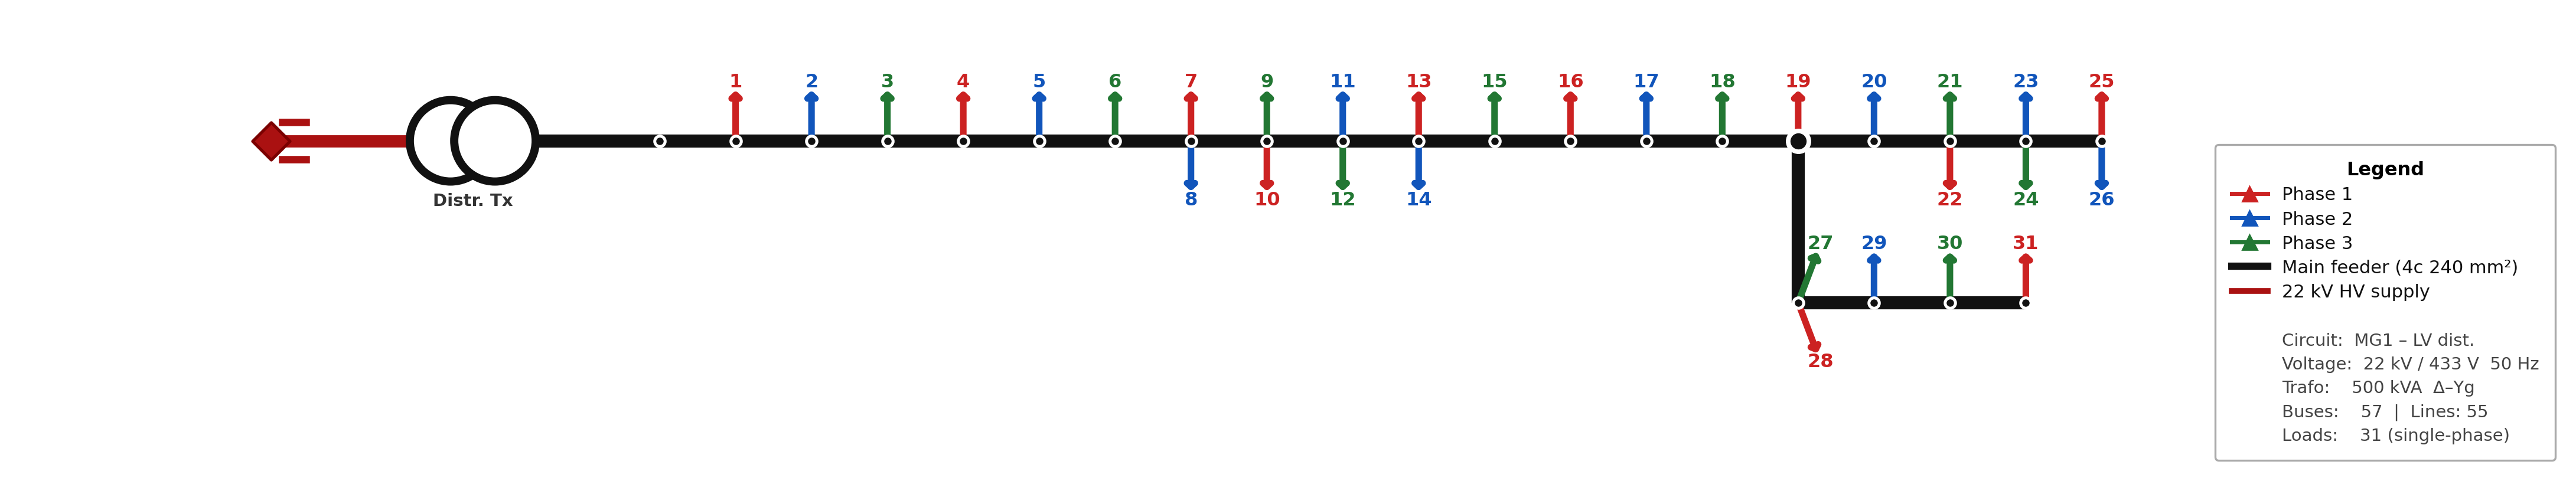


**<center>Figure 1. Simulated LV Circuit Topology</center>**


| Item | Value in the supplied dataset |
|---|---|
| Customers | 31 |
| Inputs per time step | 62 P/Q values |
| Outputs per time step | 31 voltage magnitudes |
| Sampling interval | 5 minutes |
| Training data | 6,048 rows (21 days) |
| Test data | 2,016 rows (7 days) |

<p align="center"><strong>Table 1. Data used for LV voltage estimation</strong></p>

`[P1, Q1, ..., P31, Q31]  →  neural network  →  [V1, ..., V31]`

Results apply to these simulated conditions. Accuracy on a different feeder or on real measurements would require a separate assessment.


### 2.2 Initialisation

Run the cells below in order. This notebook works both locally and in Google Colab.


#### 2.2.1 Import libraries

Start with **Prepare the runtime**, then run the import cell. **Keras** builds the neural network and **TensorFlow** performs its calculations. In Colab, the first cell installs the libraries; if a restart is requested, restart and run from that cell again.


In [1]:
#@title Prepare the runtime (run this cell)
import os
import sys
import subprocess
from pathlib import Path
import itertools
import time
import zipfile
import json
import importlib.metadata as importlib_metadata
import re

IN_COLAB = bool(os.getenv("COLAB_RELEASE_TAG") or os.getenv("COLAB_BACKEND_VERSION"))
REPO_URL = "https://github.com/Team-Nando-Capstone/Capstone_project_2026_sem1.git"
REPO_DIR = Path("/content/Capstone_project_2026_sem1")
TUTORIAL_SUBDIR = "Tutorial_1_LV_Vol_Estimation"

def installed_version(package_name):
    try:
        return importlib_metadata.version(package_name)
    except importlib_metadata.PackageNotFoundError:
        return "0"

def major_minor(version_text):
    match = re.match(r"(\d+)\.(\d+)", version_text)
    return tuple(map(int, match.groups())) if match else (0, 0)

def pandas_version_is_compatible(version_text):
    return (2, 3) <= major_minor(version_text) < (2, 4)

if IN_COLAB:
    pandas_before = installed_version("pandas")
    loaded_pandas = sys.modules.get("pandas")
    loaded_pandas_version = getattr(loaded_pandas, "__version__", None)

    # Install the runtime libraries only; Jupyter itself is already provided.
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade",
        "tensorflow>=2.16,<3", "keras>=3,<4", "numpy>=1.26",
        "pandas>=2.3,<2.4", "scikit-learn>=1.4", "matplotlib>=3.8",
    ])
    pandas_after = installed_version("pandas")
    if not pandas_version_is_compatible(pandas_after):
        raise RuntimeError(f"pandas {pandas_after} is installed, but this notebook needs pandas >=2.3,<2.4.")

    if (not pandas_version_is_compatible(pandas_before)
            or (loaded_pandas_version is not None and loaded_pandas_version != pandas_after)):
        print(f"Updated pandas from {pandas_before} to {pandas_after}.")
        print("Restarting the Colab runtime now. After it reconnects, run again from this cell.")
        os.kill(os.getpid(), 9)

os.environ["KERAS_BACKEND"] = "tensorflow"  # Set before importing Keras.

# Hide framework startup diagnostics, not Python exceptions.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"


In [2]:
import keras
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 12)
tf.get_logger().setLevel("ERROR")


The following cell prepares the tutorial files.

- **Local:** Locally, start in this tutorial folder or the project root; no ZIP upload is needed.
- **Colab:** run the cell below to clone the GitHub repository into the temporary runtime and use the checked-in tutorial files. No upload is needed.

<font color=red>Note:</font> Colab edits are temporary unless you save your own copy. Opening the GitHub Colab link again restores the original notebook version.


In [3]:
# Prepare the local working path or clone the GitHub tutorial package in Colab.
added_path = ""
if (Path.cwd() / TUTORIAL_SUBDIR).is_dir():
    added_path = TUTORIAL_SUBDIR

if IN_COLAB:
    if REPO_DIR.exists():
        subprocess.check_call(["git", "-C", str(REPO_DIR), "fetch", "--depth", "1", "origin", "main"])
        subprocess.check_call(["git", "-C", str(REPO_DIR), "reset", "--hard", "origin/main"])
        subprocess.check_call(["git", "-C", str(REPO_DIR), "clean", "-fd"])
    else:
        subprocess.check_call(["git", "clone", "--depth", "1", "--branch", "main", REPO_URL, str(REPO_DIR)])
    os.chdir(REPO_DIR / TUTORIAL_SUBDIR)
    added_path = ""

print("Working folder:", Path.cwd())


#### 2.2.2 Set the working path

The default finds the tutorial from the project root or the tutorial folder.
If Jupyter starts elsewhere, replace the first assignment below with
`TUTORIAL_DIRECTORY = Path("your/tutorial/folder")` using a path relative to
the current working directory, or with an absolute path. The next line resolves
it once. Relative `DATA_FILES` entries in Section 2.3.1 are interpreted from
this resolved tutorial directory; absolute entries are used directly.


In [4]:
TUTORIAL_DIRECTORY = Path.cwd() / added_path  # Edit this assignment if needed.
TUTORIAL_DIRECTORY = TUTORIAL_DIRECTORY.expanduser().resolve()
if not TUTORIAL_DIRECTORY.is_dir():
    raise FileNotFoundError(
        f"Tutorial directory does not exist: {TUTORIAL_DIRECTORY}. "
        "Set TUTORIAL_DIRECTORY to the folder containing this tutorial."
    )

def resolve_file(path, label):
    candidate = Path(path).expanduser()
    if not candidate.is_absolute():
        candidate = TUTORIAL_DIRECTORY / candidate
    resolved = candidate.resolve()
    if not resolved.is_file():
        raise FileNotFoundError(
            f"Missing {label}: {resolved}. Check TUTORIAL_DIRECTORY and this file entry."
        )
    return resolved

print("Tutorial directory ready:", TUTORIAL_DIRECTORY.name)


#### 2.2.3 Set the random seed

The model starts with randomly chosen weights. A **random seed** helps repeat the same starting point and training-row order. The code sets the seed and reports the initial comparison seed; results can still vary across environments.


In [5]:
SEED = 42

def set_seed(seed=SEED):
    keras.utils.set_random_seed(seed)

set_seed()
print(f"Initial comparison seed: {SEED}")


Initial comparison seed: 42


### 2.3 Simulated Data Preparation

Here, **inputs** are the P/Q values supplied to the model. **Targets** are the corresponding simulated voltages it should learn to estimate.


#### 2.3.1 Set the individual data file paths

`DATA_FOLDER` selects the supplied data location. The four entries in `DATA_FILES` are the paths you can edit; **each may point to a different folder**.

| Entry | Contents | Use |
|---|---|---|
| `PQ_tr` | Training P/Q | Training and model selection inputs |
| `V_tr` | Training voltages | Training and model selection targets |
| `PQ_te` | Test P/Q | Final-check inputs |
| `V_te` | Test voltages | Final-check targets |

The loop checks one file at a time and prints its tutorial-relative path (or filename for an external file). All values are **simulated**. In Colab, the files come from the GitHub clone created by the preparation cell.

Relative file entries start at `TUTORIAL_DIRECTORY`; absolute entries are used directly. Do not prefix a relative entry with the tutorial folder a second time.


In [6]:
# Select the supplied data folder.
DATA_FOLDER = Path("synthentic_data_5_min_LV")

# Edit individual entries here if your files are in different folders.
DATA_FILES = {
    "PQ_tr": DATA_FOLDER / "training/PQ.pkl",
    "V_tr": DATA_FOLDER / "training/V.pkl",
    "PQ_te": DATA_FOLDER / "test/PQ.pkl",
    "V_te": DATA_FOLDER / "test/V.pkl",
}

# Resolve each entry once; absolute paths are not prefixed.
data_files = {name: resolve_file(path, name) for name, path in DATA_FILES.items()}
for name, full_path in data_files.items():
    shown_path = (full_path.relative_to(TUTORIAL_DIRECTORY)
                  if full_path.is_relative_to(TUTORIAL_DIRECTORY)
                  else Path(full_path.name))
    print(f"{name}: {shown_path}")


PQ_tr: synthentic_data_5_min_LV\training\PQ.pkl
V_tr: synthentic_data_5_min_LV\training\V.pkl
PQ_te: synthentic_data_5_min_LV\test\PQ.pkl
V_te: synthentic_data_5_min_LV\test\V.pkl


#### 2.3.2 Import the training and test data

Read each file into a pandas table. `tr` means training, `te` means test, and `df` means DataFrame (a table).

The preview shows only three time steps for the first three customers; **the full data remain loaded**. Test data are kept for the final check, not for choosing model settings.


In [7]:
# Load the training inputs (P/Q) and their target voltages (V).
PQ_tr_df = pd.read_pickle(data_files["PQ_tr"])
V_tr_df = pd.read_pickle(data_files["V_tr"])

# Load the separate test inputs and target voltages for later use.
PQ_te_df = pd.read_pickle(data_files["PQ_te"])
V_te_df = pd.read_pickle(data_files["V_te"])

# iloc[row selection, column selection]: preview the first three customers.
print("First three training rows: P1, Q1, P2, Q2, P3, Q3")
display(PQ_tr_df.iloc[:3, :6])
print("Corresponding training voltages: V1, V2, V3")
display(V_tr_df.iloc[:3, :3])


First three training rows: P1, Q1, P2, Q2, P3, Q3


,0,1,2,3,4,5
0,0.120693,0.032818,0.649865,-0.296134,0.349897,0.169386
1,0.117263,0.028463,0.320885,0.139661,0.215703,0.038703
2,0.116715,-0.047785,0.822305,0.278458,0.354829,-0.133146


Corresponding training voltages: V1, V2, V3


,0,1,2
0,249.821308,249.888347,249.892601
1,249.899409,249.843989,249.866556
2,249.93567,249.821681,249.89114


#### 2.3.3 Check the data and prepare the arrays

Run the three steps below. An `assert` stops the code if a required condition is not met.

1. Check that the row and column labels match. P/Q and V must refer to the same time steps and customers; matching labels alone cannot prove that the original data were correctly paired.
2. Convert each table to a numeric `float32` array for Keras. This changes the storage format; **it does not normalise the values**.
3. Check the sizes and reject empty data, missing values or infinity.

`shape[0]` is the number of rows and `shape[1]` is the number of columns. Expect training shapes `(6048, 62)` and `(6048, 31)`, and test shapes `(2016, 62)` and `(2016, 31)`. There are 62 P/Q inputs and 31 voltage targets per time step.


In [8]:
# 1. Check that corresponding row and column labels match.
assert PQ_tr_df.index.equals(V_tr_df.index), "Training row labels differ."
assert PQ_te_df.index.equals(V_te_df.index), "Test row labels differ."
assert PQ_tr_df.columns.equals(PQ_te_df.columns), "P/Q column labels differ."
assert V_tr_df.columns.equals(V_te_df.columns), "Voltage column labels differ."

# 2. Convert each table into a numeric array for Keras.
PQ_tr = PQ_tr_df.to_numpy(dtype=np.float32)
V_tr = V_tr_df.to_numpy(dtype=np.float32)
PQ_te = PQ_te_df.to_numpy(dtype=np.float32)
V_te = V_te_df.to_numpy(dtype=np.float32)

# 3. Check matching rows, expected columns and valid numbers.
assert len(PQ_tr) == len(V_tr), "Training input and target row counts differ."
assert len(PQ_te) == len(V_te), "Test input and target row counts differ."
assert PQ_tr.shape[1] == 62, "Training inputs must have 62 P/Q columns."
assert PQ_te.shape[1] == 62, "Test inputs must have 62 P/Q columns."
assert V_tr.shape[1] == 31, "Training targets must have 31 voltage columns."
assert V_te.shape[1] == 31, "Test targets must have 31 voltage columns."

for values in [PQ_tr, V_tr, PQ_te, V_te]:
    assert len(values) > 0, "A data file is empty."
    assert np.isfinite(values).all(), "Data contain missing values or infinity."

C = V_tr.shape[1]  # One voltage column per customer: C = 31.
MINUTES_PER_STEP = 5
STEPS_PER_DAY = 24 * 60 // MINUTES_PER_STEP  # 288 time steps per day.
print("Training P/Q:", PQ_tr.shape)
print("Training V:  ", V_tr.shape)
print("Test P/Q:    ", PQ_te.shape)
print("Test V:      ", V_te.shape)


Training P/Q:

 (6048, 62)
Training V:   (6048, 31)
Test P/Q:     (2016, 62)
Test V:       (2016, 31)


#### 2.3.4 Visualise one day of power and voltage profiles

Choose `DAY_TO_PLOT` and `CUSTOMERS_TO_PLOT`. These settings only change the plot, not the training data. Each day contains 288 five-minute time steps.

P/Q columns alternate: `P1, Q1, P2, Q2, ...`. The code selects every second column to separate P and Q, then draws **P on the first panel, Q on the second, and V on the third**. Customer numbers start at 1; Python column positions start at 0, so customer 1 uses column 0.

These curves show **simulated training data, not model predictions**. Compare the power and voltage patterns. One customer's power can affect voltage elsewhere, which is why the model uses all customers' P/Q values.


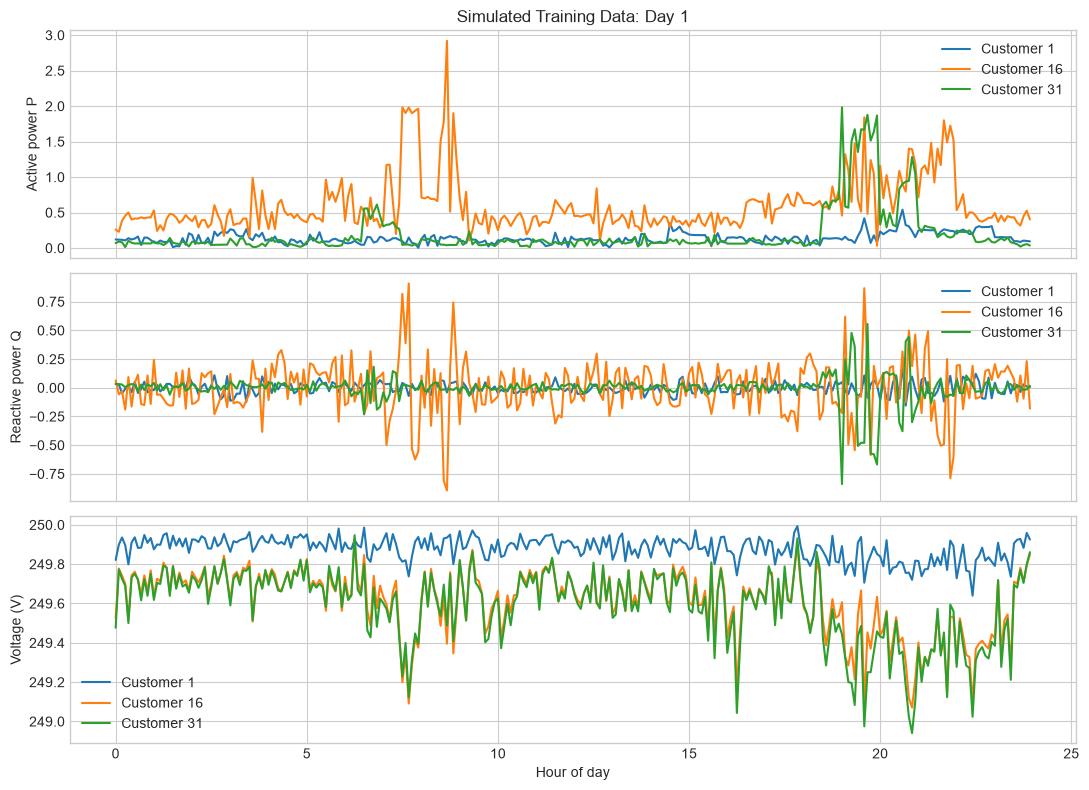

In [9]:
DAY_TO_PLOT = 1
CUSTOMERS_TO_PLOT = [1, 16, 31]

# Separate the alternating P/Q columns; keep all time steps.
P_tr = PQ_tr[:, 0::2]  # Columns 0, 2, 4, ... contain P.
Q_tr = PQ_tr[:, 1::2]  # Columns 1, 3, 5, ... contain Q.

# Check that the chosen day and customers exist.
available_days = len(PQ_tr) // STEPS_PER_DAY
if DAY_TO_PLOT < 1 or DAY_TO_PLOT > available_days:
    raise ValueError(f"Choose DAY_TO_PLOT between 1 and {available_days}.")
if not CUSTOMERS_TO_PLOT:
    raise ValueError("Choose at least one customer.")
for customer in CUSTOMERS_TO_PLOT:
    if customer < 1 or customer > C:
        raise ValueError(f"Choose customer numbers between 1 and {C}.")

# Select this day's rows and convert the time axis to hours.
start = (DAY_TO_PLOT - 1) * STEPS_PER_DAY
end = start + STEPS_PER_DAY
hours = np.arange(STEPS_PER_DAY) * MINUTES_PER_STEP / 60

# Draw one P, Q and V curve for each selected customer.
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for customer in CUSTOMERS_TO_PLOT:
    column = customer - 1
    axes[0].plot(hours, P_tr[start:end, column], label=f"Customer {customer}")
    axes[1].plot(hours, Q_tr[start:end, column], label=f"Customer {customer}")
    axes[2].plot(hours, V_tr[start:end, column], label=f"Customer {customer}")

axes[0].set_ylabel("Active power P")
axes[1].set_ylabel("Reactive power Q")
axes[2].set_ylabel("Voltage (V)")
axes[0].set_title(f"Simulated Training Data: Day {DAY_TO_PLOT}")
axes[2].set_xlabel("Hour of day")
for axis in axes:
    axis.legend(loc="best")
plt.tight_layout()
plt.show()


### 2.4 Definition of Functions

These functions are used in Section 2.5. Run their definitions first; they perform their tasks when called.


#### 2.4.1 def <font color=blue>build_model</font> (in_dim, out_dim, config, seed=SEED)

Creates a new, untrained [neural network](https://developers.google.com/machine-learning/crash-course/neural-networks/nodes-hidden-layers) using the chosen model settings.

The network takes $2C$ P/Q inputs, passes them through $H$ hidden neurons and produces $C$ voltage estimates. Each hidden neuron combines its inputs using weights and a bias.

The tutorial uses [`tanh`](https://developers.google.com/machine-learning/crash-course/neural-networks/activation-functions) in the hidden layer to learn nonlinear relationships and a linear output layer for voltage estimates. The connections in the diagram represent calculations, not electrical lines.

MSE measures the average squared error between scaled voltage predictions and targets. [Adam](https://arxiv.org/abs/1412.6980) updates weights and biases during training, while [L2 regularisation](https://developers.google.com/machine-learning/crash-course/overfitting/regularization) discourages large weights and biases.

<div align="center">
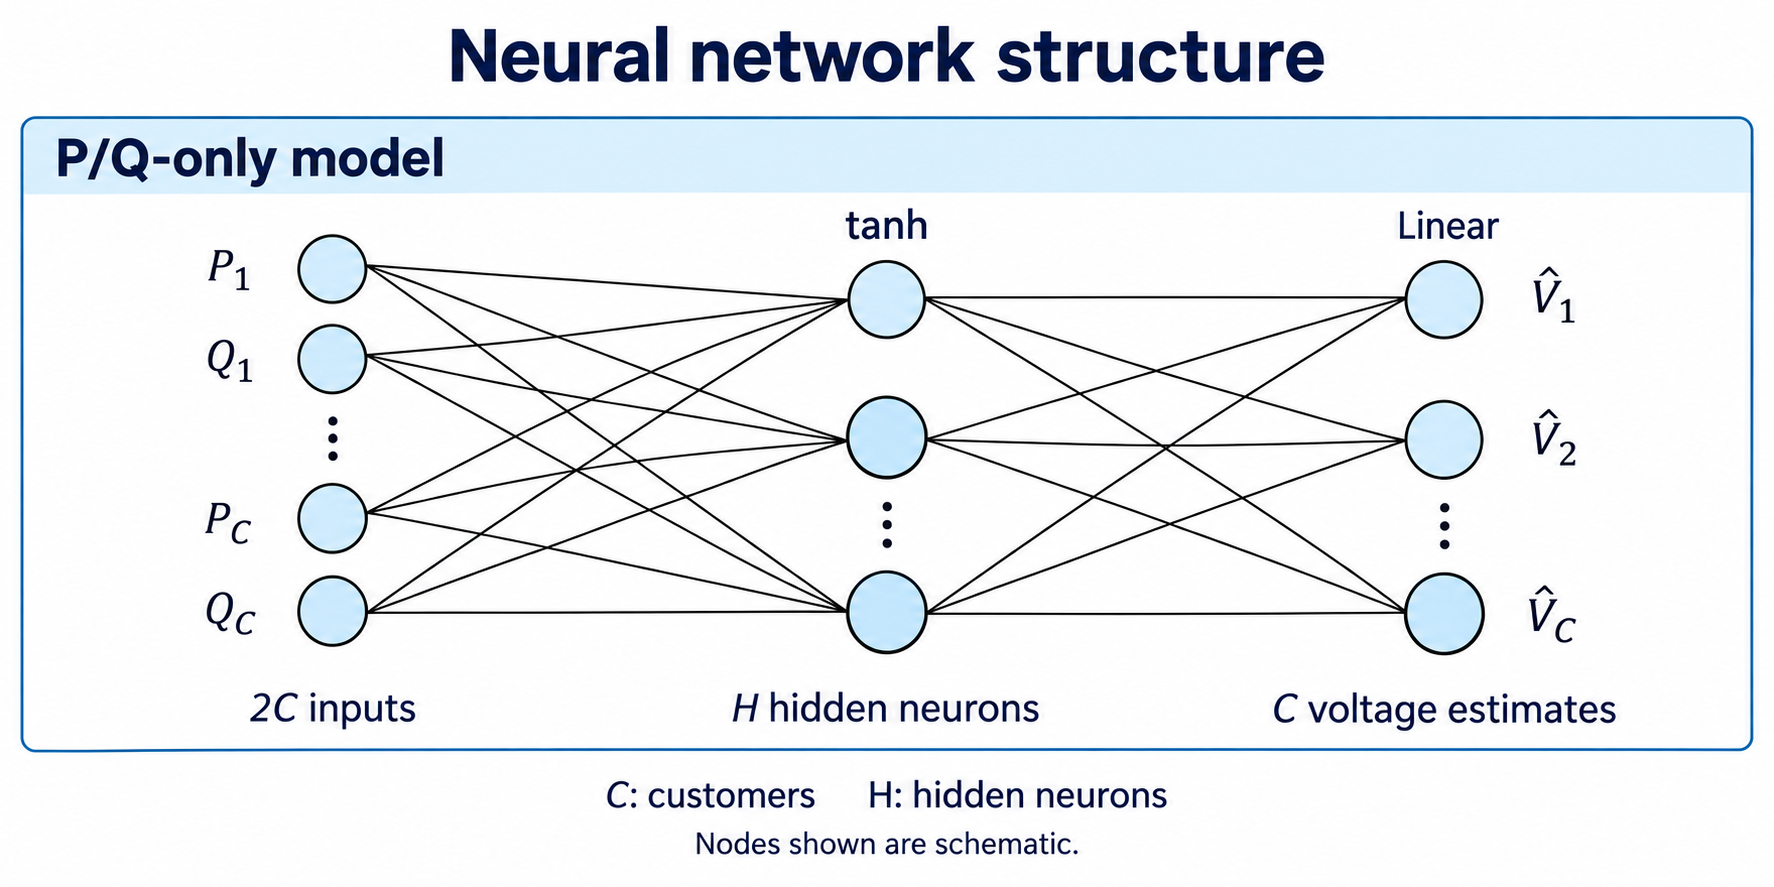
</div>

<p align="center"><strong>Figure 2. Feedforward neural network for P/Q-based voltage estimation.</strong></p>

`model.summary()` describes the untrained network. `Param #` counts weights and biases; `None` allows different batch sizes. These describe network size and shape, not prediction accuracy.


In [10]:
def build_model(in_dim, out_dim, config, seed=SEED):
    """Create a fresh Keras network for one training run."""
    keras.backend.clear_session()
    set_seed(seed)
    l2_penalty = keras.regularizers.L2(config["weight_decay"] / 2)

    model = keras.Sequential([
        keras.Input(shape=(in_dim,)),
        keras.layers.Dense(
            int(config["hidden_neurons"]),
            activation=config["activation"],
            kernel_regularizer=l2_penalty,
            bias_regularizer=l2_penalty,
        ),
        keras.layers.Dense(
            out_dim,
            activation="linear",
            kernel_regularizer=l2_penalty,
            bias_regularizer=l2_penalty,
        ),
    ], name="lv_voltage_estimator")

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=config["lr"], epsilon=1e-8
        ),
        loss="mse",
    )
    return model

example_config = {
    "hidden_neurons": 93,
    "activation": "tanh",
    "lr": 1e-3,
    "weight_decay": 1e-5,
}
example_model = build_model(2 * C, C, example_config)
example_model.summary()


Model: "lv_voltage_estimator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 93)             │         5,859 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 31)             │         2,914 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,773 (34.27 KB)

 Trainable params: 8,773 (34.27 KB)

 Non-trainable params: 0 (0.00 B)

#### 2.4.2 def <font color=blue>blocked_kfold_indices</font> (n_instances, k=3)

Splits the training rows into $K$ time blocks without shuffling. For each split, one block is used for validation and the others for training. It returns the row numbers for these splits.

Validation checks a model on rows that were not used to train it. Changing the validation block lets us check the settings on different parts of the training dataset. The separate test dataset is kept for the final check.

<div align="center">
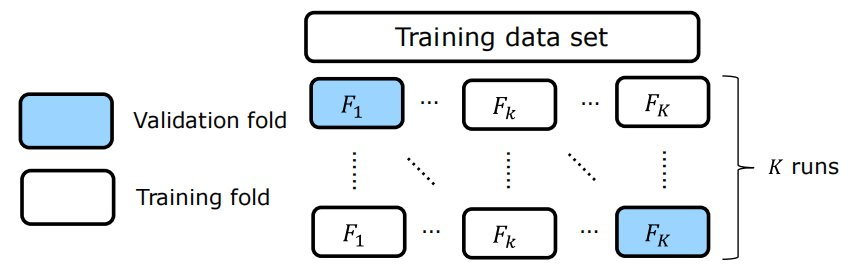
</div>

<p align="center"><strong>Figure 3. K-fold validation: each block is used for validation in turn.</strong></p>

Blue marks validation data; white marks training data. A fresh model is trained for each split.


In [11]:
def blocked_kfold_indices(n_instances, k=3):
    """Create k adjacent validation blocks without shuffling time."""
    if not 2 <= k <= n_instances:
        raise ValueError("k must be between 2 and the number of rows.")
    fold_sizes = [n_instances // k] * k
    for i in range(n_instances % k):
        fold_sizes[i] += 1

    all_indices = np.arange(n_instances)
    folds = []
    start = 0
    for fold_size in fold_sizes:
        end = start + fold_size
        validation_indices = all_indices[start:end]
        training_indices = np.concatenate(
            [all_indices[:start], all_indices[end:]]
        )
        folds.append((training_indices, validation_indices))
        start = end
    return folds


#### 2.4.3 def <font color=blue>prepare_fold</font> (PQ, V, training_indices, validation_indices)

Prepares the training and validation rows for one fold and rescales the inputs and voltages using [MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html).

Scaling puts power and voltage values on comparable numerical ranges. Each input or voltage column is scaled using its training minimum and maximum, placing training values between 0 and 1.

Only training rows are used to find these ranges. Validation rows use the same scaling rules, so they do not influence data preparation. The function returns the scaled data and both fitted scalers.


In [12]:
def prepare_fold(PQ, V, training_indices, validation_indices):
    """Fit scalers on one fold's training blocks and transform both parts."""
    PQ_train, PQ_val = PQ[training_indices], PQ[validation_indices]
    V_train, V_val = V[training_indices], V[validation_indices]

    input_scaler = MinMaxScaler().fit(PQ_train)
    output_scaler = MinMaxScaler().fit(V_train)

    X_train = input_scaler.transform(PQ_train).astype(np.float32)
    Y_train = output_scaler.transform(V_train).astype(np.float32)
    X_val = input_scaler.transform(PQ_val).astype(np.float32)
    Y_val = output_scaler.transform(V_val).astype(np.float32)

    return X_train, Y_train, X_val, Y_val, input_scaler, output_scaler


#### 2.4.4 def <font color=blue>train_model</font> (model, X_train, Y_train, config)

Uses [fit()](https://keras.io/api/models/model_training_apis/) to train the model on the prepared training data using the chosen settings.

An **epoch** is one pass through all training rows. **Batch size** is the number of rows used for each weight update. During training, the network adjusts its weights and biases to reduce the loss.

Returns the loss recorded after each epoch. This loss uses scaled voltage errors and the L2 penalty; it is not RMSE in volts.


In [13]:
def train_model(model, X_train, Y_train, config):
    """Train for the specified number of epochs."""
    history = model.fit(
        X_train,
        Y_train,
        batch_size=int(config["batch_size"]),
        epochs=int(config["epochs"]),
        shuffle=True,
        verbose=0,  # The search prints one summary for each configuration.
    )
    return history


#### 2.4.5 def <font color=blue>predict_unscaled</font> (model, X_scaled, output_scaler)

Predicts voltages from scaled inputs, then converts the predictions back to **volts** using the fitted voltage scaler.

Use the scalers already fitted for that model, not new ones fitted on the prediction data. The returned array has one row per time step and one column per target customer.


In [14]:
def predict_unscaled(model, X_scaled, output_scaler):
    """Convert model predictions back to volts."""
    scaled_prediction = model.predict(X_scaled, verbose=0)
    return output_scaler.inverse_transform(scaled_prediction)


#### 2.4.6 def <font color=blue>evaluate_config</font> (config, PQ, V, k=3, seed=SEED)

Checks one set of model settings on all $K$ folds. For each fold, it prepares the data, trains a fresh model and measures the validation RMSE (root mean squared error) in volts.

Returns the individual fold errors, their mean and their standard deviation. The mean is used to compare settings; the standard deviation shows how much the errors vary across folds.


In [15]:
def evaluate_config(config, PQ, V, k=3, seed=SEED):
    """Evaluate one configuration on all blocked folds."""
    if "hidden_neurons" in config:
        hidden_neurons = int(config["hidden_neurons"])
    else:
        hidden_neurons = round(config["hidden_multiplier"] * V.shape[1])
    fold_rmse = []
    start_time = time.time()

    for training_indices, validation_indices in blocked_kfold_indices(len(PQ), k):
        X_train, Y_train, X_val, _, _, output_scaler = prepare_fold(
            PQ, V, training_indices, validation_indices
        )

        model = build_model(
            X_train.shape[1], Y_train.shape[1],
            {**config, "hidden_neurons": hidden_neurons}, seed=seed,
        )
        train_model(model, X_train, Y_train, config)

        V_val_estimated = predict_unscaled(model, X_val, output_scaler)
        V_val = V[validation_indices]
        fold_rmse.append(
            float(np.sqrt(np.mean((V_val - V_val_estimated) ** 2)))
        )

    return {
        "hidden_neurons": hidden_neurons,
        **{f"fold_{i}_RMSE": value for i, value in enumerate(fold_rmse, 1)},
        "RMSE_kfold": float(np.mean(fold_rmse)),
        "RMSE_std": float(np.std(fold_rmse)),
        "train_time_s": float(time.time() - start_time),
    }


#### 2.4.7 def <font color=blue>run_grid_search</font> (PQ, V, search_space, k=3, seed=SEED)

Tests every combination of the candidate settings using the same folds. One configuration is one combination of settings, such as hidden-layer size and learning rate.

Returns a table ranked by mean validation RMSE, with the lowest error first. The selected settings are then used in the seed comparison.


In [16]:
def run_grid_search(PQ, V, search_space, k=3, seed=SEED):
    '''Compare all candidate settings using training-data folds only.'''
    configurations = [
        dict(zip(search_space, values))
        for values in itertools.product(*search_space.values())
    ]
    rows = []
    for number, config in enumerate(configurations, start=1):
        scores = evaluate_config(config, PQ, V, k=k, seed=seed)
        rows.append({**config, **scores})
        print(f"Configuration {number}/{len(configurations)}: "
              f"mean validation RMSE = {scores['RMSE_kfold']:.6f} V")
    return pd.DataFrame(rows).sort_values("RMSE_kfold", kind="stable").reset_index(drop=True)


#### 2.4.8 def <font color=blue>run_seed_search</font> (PQ, V, config, seeds, k=3)

Keeps the selected model settings fixed and compares random seeds. A seed controls the initial weights and training-row order, so different seeds can give slightly different errors even with the same settings.

Returns a table ranked by mean validation RMSE. This comparison chooses the seed used when training the final model.


In [17]:
def run_seed_search(PQ, V, config, seeds, k=3):
    '''Compare random seeds without using the test dataset.'''
    rows = []
    for seed in seeds:
        scores = evaluate_config(config, PQ, V, k=k, seed=seed)
        rows.append({"seed": seed, **scores})
        print(f"Seed {seed}: mean validation RMSE = {scores['RMSE_kfold']:.6f} V")
    return pd.DataFrame(rows).sort_values("RMSE_kfold", kind="stable").reset_index(drop=True)


### 2.5 Model Training and Selection

The functions are ready. Compare candidate settings, compare seeds, then train one final model using all training rows. Test data are not used for these decisions.


#### 2.5.1 Set the training mode and candidate hyperparameters

Choose `RUN_MODE` and the [training hyperparameters](https://developers.google.com/machine-learning/crash-course/linear-regression/hyperparameters) below. **Quick** mode checks the workflow; **full** allows longer training. This cell defines settings only.

**Candidate settings**

| Hyperparameter | What it controls | Quick mode | Full mode |
|---|---|---|---|
| Hidden neurons | Hidden-layer size | $3C$ or $5C$ | $3C$ or $5C$ |
| Activation | Hidden-layer nonlinearity | `tanh` | `tanh` |
| Learning rate | Size of Adam updates | `1e-3` or `1e-4` | `1e-3` or `1e-4` |
| L2 strength | Penalty on large parameters | `1e-4` or `1e-5` | `1e-4` or `1e-5` |
| Batch size | Rows per update | 72 | 72 |
| Epochs | Passes through training data | 20 or 40 | 1,000 or 2,000 |

The grid contains **16 candidate combinations**.

Larger networks or more epochs do not automatically improve validation performance. Attribute a difference to one setting only when the other settings match.

Saved outputs are from a local **quick-mode run**. After changing settings, rerun Sections 2.5–2.6. Each mode uses its own folder under `results/tutorial`; rerunning replaces its result tables.

**In Colab**, download the active tutorial's `results/tutorial/quick` (or `full`) files before the runtime ends. Saving the notebook does not save these separate files.


In [18]:
RUN_MODE = "quick"  # Change to "full" for 1,000/2,000 epochs.
if RUN_MODE not in {"quick", "full"}:
    raise ValueError('RUN_MODE must be "quick" or "full".')

SEARCH_SPACE = {
    "hidden_multiplier": [3, 5],
    "activation": ["tanh"],
    "lr": [1e-3, 1e-4],
    "weight_decay": [1e-4, 1e-5],
    "batch_size": [72],
    "epochs": [20, 40] if RUN_MODE == "quick" else [1000, 2000],
}
RESULTS_DIRECTORY = TUTORIAL_DIRECTORY / "results" / "tutorial" / RUN_MODE
RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=True)
n_configurations = int(np.prod([len(values) for values in SEARCH_SPACE.values()]))
print(f"Mode: {RUN_MODE}; candidate epochs: {SEARCH_SPACE['epochs']}")
print(f"Candidate combinations: {n_configurations}")
print("Results folder:", RESULTS_DIRECTORY.relative_to(TUTORIAL_DIRECTORY))


Mode: quick; candidate epochs: [20, 40]
Candidate combinations: 16
Results folder: results\tutorial\quick


#### 2.5.2 Set and inspect the blocked K-fold splits

Set `KFOLDS = 3`. For the supplied data, each validation block has 2,016 rows (7 days); the remaining 4,032 rows (14 days) are used for training.

Check the displayed ranges. They start at 1 for readability, while array indices start at 0. Sixteen candidates × three folds require **48 model-training runs**.


In [19]:
KFOLDS = 3
folds = blocked_kfold_indices(len(PQ_tr), k=KFOLDS)
fold_summary = pd.DataFrame([
    {
        "Fold": number,
        "Training rows": len(train_idx),
        "Validation rows": len(val_idx),
        "Validation range (1-based)": f"{val_idx[0] + 1}-{val_idx[-1] + 1}",
    }
    for number, (train_idx, val_idx) in enumerate(folds, start=1)
])
display(fold_summary)
print(f"Grid-search model fits: {n_configurations} x {KFOLDS} = {n_configurations * KFOLDS}")


,Fold,Training rows,Validation rows,Validation range (1-based)
0,1,4032,2016,1-2016
1,2,4032,2016,2017-4032
2,3,4032,2016,4033-6048


Grid-search model fits: 16 x 3 = 48


#### 2.5.3 Select hyperparameters using blocked K-fold validation

Run the grid search to rank configurations. Log numbers follow execution order, not the table's error ranking. The selected settings are used for fresh final training in Section 2.5.5.

- `RMSE_kfold`: mean validation error in volts; the lowest value ranks first.
- `RMSE_std`: standard deviation of fold RMSE values for this configuration, in volts.
- The first row supplies `best_config`; the other columns identify its settings.

The table is calculated by this run and saved as `LV_keras_search_results.csv`. These are validation results, not final test results.


In [20]:
search_results = run_grid_search(PQ_tr, V_tr, SEARCH_SPACE, k=KFOLDS, seed=SEED)
search_results.to_csv(RESULTS_DIRECTORY / "LV_keras_search_results.csv", index=False)

columns_to_show = ["hidden_neurons", "activation", "lr", "weight_decay",
                   "batch_size", "epochs", "RMSE_kfold", "RMSE_std"]
display(search_results[columns_to_show].round(6))

best_row = search_results.iloc[0]
best_config = {
    "hidden_neurons": int(best_row["hidden_neurons"]),
    "activation": str(best_row["activation"]),
    "lr": float(best_row["lr"]),
    "weight_decay": float(best_row["weight_decay"]),
    "batch_size": int(best_row["batch_size"]),
    "epochs": int(best_row["epochs"]),
}
print("Selected settings:", best_config)
print(f"Mean validation RMSE: {best_row['RMSE_kfold']:.6f} V")


Configuration 1/16: mean validation RMSE = 0.123115 V


Configuration 2/16: mean validation RMSE = 0.093653 V


Configuration 3/16: mean validation RMSE = 0.122379 V


Configuration 4/16: mean validation RMSE = 0.081666 V


Configuration 5/16: mean validation RMSE = 0.314992 V


...

Configuration 14/16: mean validation RMSE = 0.213671 V


Configuration 15/16: mean validation RMSE = 0.298685 V


Configuration 16/16: mean validation RMSE = 0.213570 V


,hidden_neurons,activation,lr,weight_decay,batch_size,epochs,RMSE_kfold,RMSE_std
0,155,tanh,0.0010,0.00001,72,40,0.075256,0.003544
1,93,tanh,0.0010,0.00001,72,40,0.081666,0.004465
2,155,tanh,0.0010,0.00010,72,40,0.088135,0.003871
3,93,tanh,0.0010,0.00010,72,40,0.093653,0.005698
4,155,tanh,0.0010,0.00001,72,20,0.106591,0.005095
5,155,tanh,0.0010,0.00010,72,20,0.110390,0.005382
6,93,tanh,0.0010,0.00001,72,20,0.122379,0.004804
7,93,tanh,0.0010,0.00010,72,20,0.123115,0.004773
8,155,tanh,0.0001,0.00001,72,40,0.213570,0.003469
9,155,tanh,0.0001,0.00010,72,40,0.213671,0.003793


Selected settings: {'hidden_neurons': 155, 'activation': 'tanh', 'lr': 0.001, 'weight_decay': 1e-05, 'batch_size': 72, 'epochs': 40}
Mean validation RMSE: 0.075256 V


#### 2.5.4 Compare and select random seeds

With the selected configuration fixed, compare seeds **0–9** on the same three folds and choose the lowest mean validation RMSE.

Compare mean RMSE across rows to assess seed sensitivity; `RMSE_std` describes variation between folds for each seed, not between seeds.

The saved configuration search used seed 42, which is not included in this seed comparison. The selected seed's score therefore need not improve on the previous step.


In [21]:
SEEDS_TO_TRY = list(range(10))
seed_results = run_seed_search(PQ_tr, V_tr, best_config, SEEDS_TO_TRY, k=KFOLDS)
selected_seed = int(seed_results.iloc[0]["seed"])
display(seed_results[["seed", "RMSE_kfold", "RMSE_std"]].round(6))
seed_results.to_csv(RESULTS_DIRECTORY / "LV_keras_seed_results.csv", index=False)
print(f"Selected seed: {selected_seed}")


Seed 0: mean validation RMSE = 0.075048 V


Seed 1: mean validation RMSE = 0.069666 V


Seed 2: mean validation RMSE = 0.076155 V


Seed 3: mean validation RMSE = 0.073398 V


Seed 4: mean validation RMSE = 0.075152 V


...

Seed 7: mean validation RMSE = 0.074835 V


Seed 8: mean validation RMSE = 0.072435 V


Seed 9: mean validation RMSE = 0.073576 V


,seed,RMSE_kfold,RMSE_std
0,1,0.069666,0.003863
1,5,0.070519,0.001058
2,8,0.072435,0.002491
3,3,0.073398,0.000738
4,6,0.073547,0.000961
5,9,0.073576,0.001162
6,7,0.074835,0.002840
7,0,0.075048,0.002759
8,4,0.075152,0.002126
9,2,0.076155,0.002292


Selected seed: 1


#### 2.5.5 Train the final model on all training data

Using the selected configuration and seed, train a fresh network on the complete training dataset. No validation block is held out: every training row contributes to the final model. The independent test dataset remains unused.

Fit new input and target scalers on all training rows, then train for the selected number of epochs. Use the resulting model and fitted scalers for test evaluation in Section 2.6.


In [22]:
input_scaler_full = MinMaxScaler().fit(PQ_tr)
output_scaler_full = MinMaxScaler().fit(V_tr)
X_train_full = input_scaler_full.transform(PQ_tr).astype(np.float32)
Y_train_full = output_scaler_full.transform(V_tr).astype(np.float32)

FINAL_MODEL = build_model(2 * C, C, best_config, seed=selected_seed)
final_history = train_model(FINAL_MODEL, X_train_full, Y_train_full, best_config)

print(f"Final model trained for {len(final_history.epoch)} epochs.")
print(f"Mode: {RUN_MODE}; hidden neurons: {best_config['hidden_neurons']}; seed: {selected_seed}")
print("No test data were used for training or model selection.")

run_settings = {
    "mode": RUN_MODE, "configuration": best_config, "selected_seed": selected_seed,
    "folds": KFOLDS, "seeds_compared": SEEDS_TO_TRY,
    "training_runs": n_configurations * KFOLDS + len(SEEDS_TO_TRY) * KFOLDS + 1,
    "completed_epochs": len(final_history.epoch),
}
with (RESULTS_DIRECTORY / "LV_keras_run_settings.json").open("w", encoding="utf-8") as settings_file:
    json.dump(run_settings, settings_file, indent=2)


Final model trained for 40 epochs.
Mode: quick; hidden neurons: 155; seed: 1
No test data were used for training or model selection.


### 2.6 Further Analysis of the Results

Apply the final model from Section 2.5 to the held-out test data. This section examines the overall error, voltage-profile agreement and differences between customers.

Customer locations in Figure 1 provide topology context for interpreting the errors. However, topology is not an explicit model input, so an observed spatial pattern does not by itself establish its physical cause.


#### 2.6.1 Evaluate the held-out test data

Transform test P/Q using the existing training scaler, predict voltages and restore the outputs to volts. Do not fit a new scaler on test data.

Define error as:

$$
\text{error} = \text{estimate} - \text{simulated reference}
$$

Positive error indicates overestimation and negative error indicates underestimation.

- **RMSE** gives more weight to larger errors.
- **MAE** is the average absolute error.

For the saved quick-mode run:

- Overall RMSE: **0.054894 V**
- Overall MAE: **0.039941 V**

Both values are calculated over all test rows and all 31 customers. Use these results to report final performance, not to retune the model.


In [23]:
X_test_full = input_scaler_full.transform(PQ_te).astype(np.float32)
V_test_estimated = predict_unscaled(FINAL_MODEL, X_test_full, output_scaler_full)
test_error = V_test_estimated - V_te

test_rmse = float(np.sqrt(np.mean(test_error ** 2)))
test_mae = float(np.mean(np.abs(test_error)))
per_customer_rmse = np.sqrt(np.mean(test_error ** 2, axis=0))

test_metrics = pd.DataFrame({
    "Mode": [RUN_MODE, RUN_MODE],
    "Metric": ["Overall RMSE", "Mean absolute error"],
    "Value (V)": [test_rmse, test_mae],
})
display(test_metrics.round(6))
test_metrics.to_csv(RESULTS_DIRECTORY / "LV_keras_test_metrics.csv", index=False)
print("The following plots all use these same test predictions; no model is retrained.")


,Mode,Metric,Value (V)
0,quick,Overall RMSE,0.054894
1,quick,Mean absolute error,0.039941


The following plots all use these same test predictions; no model is retrained.


#### 2.6.2 Compare estimated and simulated voltage profiles

Choose `TEST_DAY_TO_PLOT` and `CUSTOMER_TO_PLOT`.

- **Left:** compare the estimated and simulated voltage profiles for the selected day and customer.
- **Right:** compare all test estimates with their simulated references. Points on the diagonal agree exactly; points above it overestimate and points below it underestimate.

The left panel shows whether the model follows the timing and shape of one voltage profile. The spread around the diagonal in the right panel shows the error distribution across all test rows and customers.

Changing the displayed day or customer changes only the view, not the trained model.


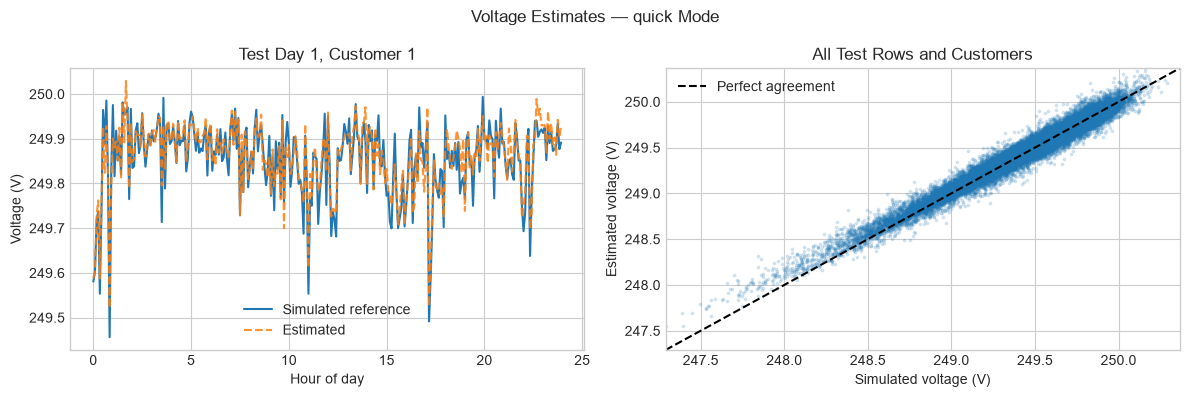

In [24]:
TEST_DAY_TO_PLOT = 1
CUSTOMER_TO_PLOT = 1

test_days = len(V_te) // STEPS_PER_DAY
if not 1 <= TEST_DAY_TO_PLOT <= test_days:
    raise ValueError(f"Choose TEST_DAY_TO_PLOT between 1 and {test_days}.")
if not 1 <= CUSTOMER_TO_PLOT <= C:
    raise ValueError(f"Choose CUSTOMER_TO_PLOT between 1 and {C}.")

test_start = (TEST_DAY_TO_PLOT - 1) * STEPS_PER_DAY
test_end = test_start + STEPS_PER_DAY
customer_index = CUSTOMER_TO_PLOT - 1
hours = np.arange(STEPS_PER_DAY) * MINUTES_PER_STEP / 60
limits = [min(float(V_te.min()), float(V_test_estimated.min())),
          max(float(V_te.max()), float(V_test_estimated.max()))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hours, V_te[test_start:test_end, customer_index], label="Simulated reference")
axes[0].plot(hours, V_test_estimated[test_start:test_end, customer_index],
             label="Estimated", linestyle="--", alpha=0.85)
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Voltage (V)")
axes[0].set_title(f"Test Day {TEST_DAY_TO_PLOT}, Customer {CUSTOMER_TO_PLOT}")
axes[0].legend()

axes[1].scatter(V_te.ravel(), V_test_estimated.ravel(), s=3, alpha=0.15)
axes[1].plot(limits, limits, "k--", label="Perfect agreement")
axes[1].set_xlim(limits)
axes[1].set_ylim(limits)
axes[1].set_xlabel("Simulated voltage (V)")
axes[1].set_ylabel("Estimated voltage (V)")
axes[1].set_title("All Test Rows and Customers")
axes[1].legend()
fig.suptitle(f"Voltage Estimates — {RUN_MODE} Mode")
plt.tight_layout()
plt.show()


#### 2.6.3 Compare voltage errors across customers

Compare each customer's RMSE over the test period. Bars remain in customer order so they can be related to Figure 1; the table lists the five largest errors.

In the saved quick-mode run, the five highest-RMSE customers are C18, C17, C21, C26 and C19. These customers are located in the mid- or downstream parts of the feeder.

Across all customers, RMSE has an overall tendency to increase with topological distance from the transformer, but the relationship is not monotonic. Some distant customers have relatively low errors, so distance alone does not explain the result.

A physically plausible reason for the overall trend is that voltages farther along the feeder are affected by the cumulative voltage drops and load interactions along a longer electrical path. This can make the P/Q-to-voltage relationship more sensitive downstream. However, physical voltage sensitivity is not the same as neural-network estimation error; data coverage and model fit also affect the RMSE.

A higher bar means a larger estimation error, not a higher voltage.


,Customer,RMSE (V)
17,18,0.085399
16,17,0.077979
20,21,0.076296
25,26,0.075472
18,19,0.073828


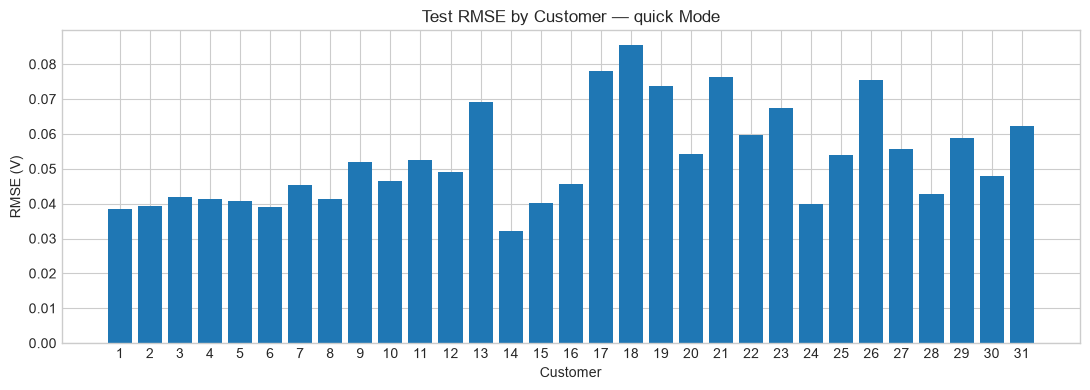

In [25]:
customer_errors = pd.DataFrame({
    "Customer": np.arange(1, C + 1),
    "RMSE (V)": per_customer_rmse,
})
customer_errors.to_csv(RESULTS_DIRECTORY / "LV_keras_per_customer_results.csv", index=False)
display(customer_errors.sort_values("RMSE (V)", ascending=False).head(5).round(6))

fig, axis = plt.subplots(figsize=(11, 4))
axis.bar(customer_errors["Customer"], customer_errors["RMSE (V)"])
axis.set_xlabel("Customer")
axis.set_ylabel("RMSE (V)")
axis.set_title(f"Test RMSE by Customer — {RUN_MODE} Mode")
axis.set_xticks(np.arange(1, C + 1))
plt.tight_layout()
plt.show()


#### 2.6.4 Inspect the customer with the highest error

Inspect the highest-RMSE customer over the full test period. In the saved quick-mode run, this is **customer 18**, with an RMSE of **0.085399 V**.

C18 is located in the mid-feeder section rather than at the most distant feeder position. This is another indication that the distance trend is not a rule for every customer.

The upper panel compares the simulated and estimated voltages. The lower panel shows the residual:

$$
\text{residual} = \text{estimate} - \text{simulated reference}
$$

The mean signed error for C18 is **+0.000282 V**, which is close to zero. This does not mean its RMSE is small: positive and negative errors can cancel in the signed mean while their magnitudes still contribute to RMSE.

These plots locate errors in time and along the feeder, but they do not establish their physical cause.

The workflow is complete: **prepare data → validate settings → compare seeds → train the final model → assess test voltages**.


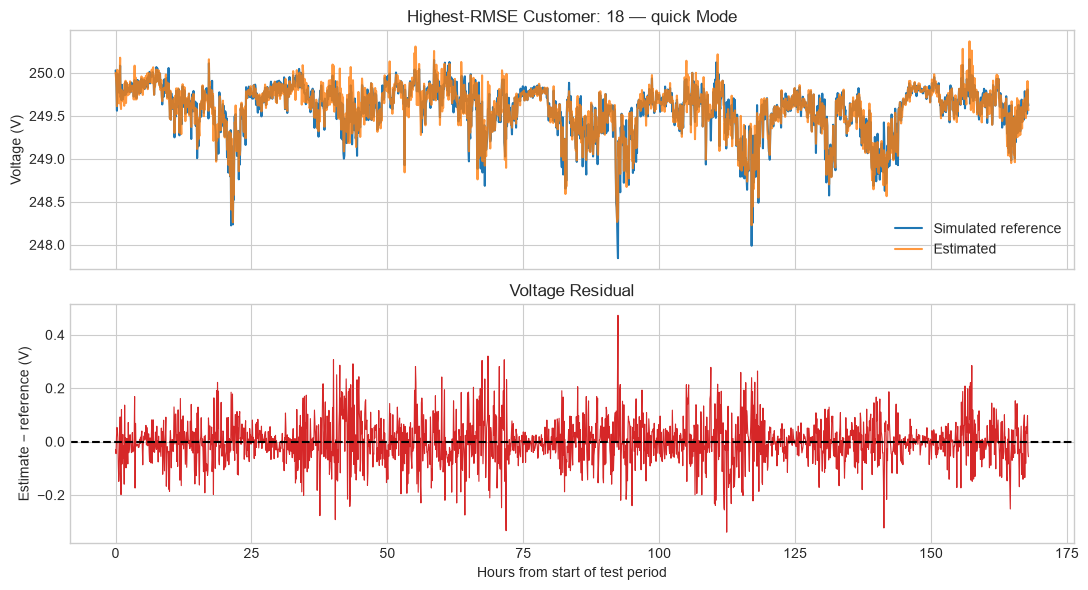

Customer: 18
Customer RMSE: 0.085399 V
Mean signed error: +0.000282 V


In [26]:
worst_customer = int(np.argmax(per_customer_rmse))
test_hours = np.arange(len(V_te)) * MINUTES_PER_STEP / 60

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(test_hours, V_te[:, worst_customer], label="Simulated reference")
axes[0].plot(test_hours, V_test_estimated[:, worst_customer], label="Estimated", alpha=0.8)
axes[0].set_ylabel("Voltage (V)")
axes[0].set_title(f"Highest-RMSE Customer: {worst_customer + 1} — {RUN_MODE} Mode")
axes[0].legend()

axes[1].plot(test_hours, test_error[:, worst_customer], color="tab:red", linewidth=0.8)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xlabel("Hours from start of test period")
axes[1].set_ylabel("Estimate − reference (V)")
axes[1].set_title("Voltage Residual")
plt.tight_layout()
plt.show()

print(f"Customer: {worst_customer + 1}")
print(f"Customer RMSE: {per_customer_rmse[worst_customer]:.6f} V")
print(f"Mean signed error: {test_error[:, worst_customer].mean():+.6f} V")


## 3. Exercises

Read both exercises before starting. Use the relevant code from **2. Tutorial** in **4. Exercise Workspace**. Complete the tasks in order and show your results using code, tables and plots; no written explanations are required.

Both exercises use the same **simulated P/Q and voltage data** as the tutorial. The aim is to practise training a neural network to estimate customer voltages.

<font color='red'>**<u>Note</u>:**</font> Use only training-data folds to choose network settings and seeds. Use the test data only in **E2.3–E2.4**, after these choices are fixed. This is a classroom reuse of the tutorial's test set, not a new independent test. Do not retune the model using its test results.


### **Exercise 1: Modifying the Neural Network**

Start with the network below. You will first increase the number of hidden neurons, then change the activation function. For every case, use **three blocked folds**, with scalers fitted only on the training rows of each fold, as in **2.4.3**.

| Setting | Starting value |
|---|---|
| Hidden neurons | 93 |
| Hidden-layer activation | `tanh` |
| Learning rate | `1e-3` |
| L2 strength (`weight_decay`) | `1e-5` |
| Batch size | 72 |
| Epochs | 40 |
| Random seed | 42 |

Keep the learning rate, L2 strength, batch size, epochs and seed unchanged throughout Exercise 1. The **40-epoch** budget is a short classroom run, separate from `RUN_MODE`; it is not the tutorial's full training budget.


**E1.1:** Train and validate the network with **93 hidden neurons and `tanh`** using the three blocked folds. Display the mean validation RMSE and its standard deviation, both in **V**.

**E1.2:** Increase the hidden-neuron count to **155**, keeping `tanh` and all other settings unchanged. Repeat E1.1 for this network.

Now change the hidden-layer activation from **`tanh` to `relu`**. This uses the same model-building code; only the activation setting changes.

**E1.3:** Train and validate networks with **93 and 155 hidden neurons using `relu`**. Combine these results with E1.1–E1.2 in one table showing the hidden-neuron count, activation, epochs, mean validation RMSE and standard deviation. Sort the four cases from lowest to highest mean validation RMSE. Store and display the settings of the first case as **`e1_best_config`** for Exercise 2.

> - Reuse `evaluate_config()` from **2.4.6** for each case. It prepares the folds and calls the model-building, training and voltage-prediction functions for you.
> - Keep each configuration together with its returned scores, as in **2.4.7**. Follow **2.5.3** to turn the best row into a configuration dictionary.

Four cases with three folds require **12 training runs**. Do not rerun the earlier cases when assembling the comparison table.


### **Exercise 2: Training and Testing the Voltage Estimator**

Use **`e1_best_config`** from Exercise 1 to complete the training and test procedure. Build a **new model** for the final training run; do not reuse a model already trained on one fold or the tutorial's `FINAL_MODEL`.

Use the following conditions:

- **Network and training settings:** the selected Exercise 1 configuration, including **40 epochs**.
- **Seeds to compare:** **0, 1 and 2**, using the same **three blocked folds**.
- **Final training data:** all rows of `PQ_tr` and `V_tr`.
- **Test inputs and reference voltages:** `PQ_te` and `V_te`.


**E2.1:** Compare seeds **0, 1 and 2** using the selected configuration. Display the mean validation RMSE and its standard deviation for each seed. Store the seed with the lowest mean validation RMSE as **`e2_selected_seed`** and display it together with `e1_best_config`.

**E2.2:** Fit new input and output scalers on **all training rows only**. Build a new network using `e1_best_config` and `e2_selected_seed`, then train it on the scaled training data. Display the model summary and the number of completed epochs.

**E2.3:** Use the trained network to estimate voltages from the **test P/Q**. Apply the fitted input scaler without refitting it, and restore the network outputs to **V**. Display the overall test **RMSE and MAE**, and a table of **RMSE for all 31 customers**.

**E2.4:** Find the customer with the highest test RMSE. Display its customer number and RMSE. For this customer, plot the **simulated and estimated voltages** together, with a second plot showing their difference (**estimate − simulated reference**) over the whole test period.

> - Reuse `run_seed_search()` and **2.5.4–2.5.5** for seed selection and final training.
> - Reuse **2.6.1** for predictions and errors, **2.6.3** for the customer table, and **2.6.4** for the voltage and error plots. Use your exercise model and exercise variables throughout.

Exercise 2 requires **9 seed-validation runs and 1 final training run**. Both exercises together require **22 training runs**.


## 4. Exercise Workspace

Complete **E1.1–E1.3**, then **E2.1–E2.4**. Add the relevant tutorial code below each task label and display the requested results. The comments are starting points, not completed solutions.

In a fresh kernel, run **2.2–2.4** first to load the data and define the functions. You do not need to run **2.5–2.6** again. Use `e1_` and `e2_` variable names to keep your exercise work separate from the tutorial's results.


### Exercise 1: Modifying the Neural Network


In [ ]:
# E1.1 — Starting network: 93 hidden neurons, tanh.
e1_config = {
    "hidden_neurons": 93,
    "activation": "tanh",
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "batch_size": 72,
    "epochs": 40,
}
e1_seed = 42
e1_k = 3
e1_rows = []

# TODO: call evaluate_config() with e1_config, PQ_tr, V_tr, e1_k and e1_seed.
# Display the returned RMSE_kfold and RMSE_std values in volts.
# Save a COPY of this configuration and its scores as one row in e1_rows.


In [ ]:
# E1.2 — Change only the hidden-neuron count to 155.
# TODO: copy e1_config with .copy(), then change "hidden_neurons".
# Evaluate the new configuration on the same three folds with seed 42.
# Display the scores and append this configuration and its scores to e1_rows.


In [ ]:
# E1.3 — Repeat with relu for 93 and 155 hidden neurons.
# TODO: copy e1_config for each case; change hidden_neurons and activation.
# Evaluate each case and append its configuration and scores to e1_rows.

# TODO: create e1_results = pd.DataFrame(e1_rows).
# Sort by "RMSE_kfold" (lowest first) and display:
# hidden_neurons, activation, epochs, RMSE_kfold, RMSE_std.

# TODO: follow Section 2.5.3 to create e1_best_config from the best row.
# Include hidden_neurons, activation, lr, weight_decay, batch_size and epochs.
# Display e1_best_config. Keep it unchanged throughout Exercise 2.


### Exercise 2: Training and Testing the Voltage Estimator


In [ ]:
# E2.1 — Compare seeds using the selected Exercise 1 configuration.
e2_seeds = [0, 1, 2]

# TODO: call run_seed_search() with PQ_tr, V_tr, e1_best_config,
# e2_seeds and k=3. Store the returned table as e2_seed_results.
# Display seed, RMSE_kfold and RMSE_std.
# Store the first row's seed as e2_selected_seed (an integer).
# Display e1_best_config and e2_selected_seed.


In [ ]:
# E2.2 — Train a new model on all training rows.
# TODO: fit e2_input_scaler and e2_output_scaler on PQ_tr and V_tr only.
# Transform the training arrays to obtain e2_X_train and e2_Y_train.
# Use build_model() to create e2_model with e1_best_config and e2_selected_seed.
# Use train_model() and store the returned history as e2_history.
# Display e2_model.summary() and len(e2_history.epoch).


In [ ]:
# E2.3 — Estimate test voltages and calculate errors in volts.
# TODO: transform PQ_te with e2_input_scaler; do not fit a new scaler.
# Use predict_unscaled() with e2_model and e2_output_scaler.
# Store the estimates as e2_V_estimated.
# Calculate e2_error = e2_V_estimated - V_te.
# Display overall RMSE and MAE, then a table of RMSE for customers 1 to 31.


In [ ]:
# E2.4 — Plot the highest-RMSE customer's voltage estimates.
# TODO: find the customer with the highest RMSE from E2.3.
# Display its customer number (array index + 1) and RMSE in volts.
# Adapt Section 2.6.4 using e2_V_estimated and e2_error.
# Plot simulated and estimated voltages over the full test period.
# Below them, plot estimate - simulated reference, with a zero-error line.
